In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset,Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import itertools

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Dataset & Tokenizer

In [ ]:
#%%script echo skip

from datasets import load_dataset

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")

In [ ]:
print(ds)
print(ds['train']['label'])

In [ ]:
train_data=ds['train']
val_data=ds['validation']
test_data=ds['test']

In [ ]:
class MovieDataset(Dataset):
  def __init__(self, dataset, tokenizer):
    self.data=dataset
    self.encoded_texts=[
        tokenizer.encode(text) for text in dataset['text']
    ]

  def __getitem__(self, idx):
    encoded=self.encoded_texts[idx]
    label=self.data[idx]['label']
    return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)


  def __len__(self):
    return len(self.data)

pad -> eos

In [ ]:
def collate_fn(
    batch,
    eos_id=50256,
    pad_id=50256,
    allowed_max_len=None,
    device='cpu'
):
  batch_max_len=max(len(item[0])+1 for item in batch)
  inputs_lst, targets_lst=[] , []

  for item_text,tgt in batch:
    item_text = torch.cat([
        item_text,
        torch.tensor([eos_id], dtype=torch.long)
    ])

    inp=torch.cat([
        item_text,
        torch.tensor([pad_id]*(batch_max_len-len(item_text)), dtype=torch.long)
    ])

    if allowed_max_len is not None:
      inp=inp[:allowed_max_len]

    inputs_lst.append(inp)
    targets_lst.append(tgt)

  inputs=torch.stack(inputs_lst).to(device)
  targets=torch.tensor(targets_lst).to(device)

  return inputs, targets

In [ ]:
import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>",allowed_special={"<|endoftext|>"}))

# Setting

In [ ]:
num_workers=0
batch_size=32
device='cuda' if torch.cuda.is_available() else 'cpu'

pad -> eos

In [ ]:
class GPTConfig:
  max_len: int = 1024
  vocab_size: int = tokenizer.n_vocab
  layers: int = 12
  heads: int = 12
  d_model: int = 768
  attn_drop: float = 0.1
  resid_drop: float = 0.1
  embed_drop: float = 0.1
  bias: bool = True
  weight_tying: bool = False
  pad_id: int = 50256
  eos_id: int = 50256

In [ ]:
print(GPTConfig.vocab_size)

In [ ]:
from functools import partial
collate_fn_partial=partial(
    collate_fn,
    device=device,
    allowed_max_len=GPTConfig.max_len,
    pad_id=GPTConfig.pad_id,
    eos_id=GPTConfig.eos_id
)

In [ ]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer, eos_id=50256):
    flat = token_ids.squeeze(0).tolist()
    flat = [t for t in flat if t != eos_id]
    return tokenizer.decode(flat)

In [ ]:
train_ds=MovieDataset(train_data, tokenizer)
val_ds=MovieDataset(val_data, tokenizer)
test_ds=MovieDataset(test_data, tokenizer)

print("train dataset")
train_loader=DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_partial,
    drop_last=True,
    num_workers=num_workers
)

print("validation dataset")
val_loader=DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_partial,
    drop_last=True,
    num_workers=num_workers
)

print("test dataset")
test_loader=DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_partial,
    drop_last=True,
    num_workers=num_workers
)

print('-'*60,end='\n\n')
data_iter=iter(train_loader)
inputs, targets=next(data_iter)

print(token_ids_to_text(inputs[0], tokenizer) + "  " + str(targets[0]))
print(token_ids_to_text(inputs[1], tokenizer) + "  " + str(targets[1]))

# Architecture

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, heads, attn_dropout=0.0,resid_drop=0.0,qkv_bias=True):
    super(MultiHeadAttention,self).__init__()
    assert(d_model % heads == 0)
    self.d_model = d_model
    self.heads = heads
    self.head_dim = d_model // heads

    self.query=nn.Linear(d_model,d_model,bias=qkv_bias)
    self.key=nn.Linear(d_model,d_model,bias=qkv_bias)
    self.value=nn.Linear(d_model,d_model,bias=qkv_bias)
    self.out_fc=nn.Linear(d_model,d_model,bias=qkv_bias)
    self.attn_dropout=nn.Dropout(attn_dropout)
    self.resid_dropout=nn.Dropout(resid_drop)



  def forward(self,q,k,v,mask=None):
    batch_size=q.shape[0]
    q_len,k_len,v_len=q.shape[1],k.shape[1],v.shape[1]

    q=self.query(q).view(batch_size,q_len,self.heads,self.head_dim)
    k=self.key(k).view(batch_size,k_len,self.heads,self.head_dim)
    v=self.value(v).view(batch_size,v_len,self.heads,self.head_dim)

    energy=torch.einsum("nqhd,nkhd->nhqk",[q,k])

    if mask is not None:
      energy=energy.masked_fill(mask==0,-torch.inf)

    attention=torch.softmax(energy/(self.head_dim**(1/2)),dim=-1)
    attention=self.attn_dropout(attention)

    out=torch.einsum("nhql,nlhd->nqhd",[attention,v])
    out=out.reshape(batch_size,q_len,self.d_model)
    out=self.out_fc(out)
    out=self.resid_dropout(out)
    return out

In [ ]:
class FeedForward(nn.Module):
  def __init__(self,d_model,dropout=0.0,bias=True):
    super(FeedForward,self).__init__()
    self.layers=nn.Sequential(
        nn.Linear(d_model,d_model*4,bias=bias),
        nn.GELU(),
        nn.Linear(d_model*4,d_model,bias=bias)
    )
    self.dropout=nn.Dropout(dropout)

  def forward(self,x):
    x=self.layers(x)
    x=self.dropout(x)
    return x

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super(TransformerBlock,self).__init__()
    self.norm1=nn.LayerNorm(cfg.d_model,bias=cfg.bias)
    self.attn=MultiHeadAttention(cfg.d_model,cfg.heads,cfg.attn_drop,cfg.resid_drop,cfg.bias)
    self.norm2=nn.LayerNorm(cfg.d_model,bias=cfg.bias)
    self.ff=FeedForward(cfg.d_model,cfg.resid_drop,bias=cfg.bias)

  def forward(self,x,mask=None):
    shortcut=x
    x=self.norm1(x)
    x=shortcut+self.attn(x,x,x,mask)
    x=x+self.ff(self.norm2(x))
    return x

pad -> eos

In [ ]:
class GPT2(nn.Module):
  def __init__(self,cfg):
    super(GPT2,self).__init__()
    assert cfg.max_len is not None
    assert cfg.vocab_size is not None
    self.cfg=cfg

    self.tok_emb=nn.Embedding(cfg.vocab_size,cfg.d_model)
    self.pos_emb=nn.Embedding(cfg.max_len,cfg.d_model)
    self.drop=nn.Dropout(cfg.embed_drop)

    self.blocks=nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.layers)])

    self.norm=nn.LayerNorm(cfg.d_model,bias=cfg.bias)
    self.head=nn.Linear(cfg.d_model,cfg.vocab_size,bias=cfg.bias)

    self.pad_idx=cfg.pad_id

    if cfg.weight_tying:
      self.tok_emb.weight=self.head.weight

  def make_causal_mask(self, x):
    device = x.device
    batch_size, seq_len = x.shape

    # 각 위치의 인덱스를 나열
    positions = torch.arange(seq_len, device=device).unsqueeze(0).expand_as(x)

    # eos(=pad_idx)가 아닌 위치는 seq_len(범위 밖 큰 값)으로 채우고,
    # 그 중 최솟값 = "진짜 처음 나온 eos의 위치"
    is_eos = (x == self.pad_idx)
    eos_positions = positions.masked_fill(~is_eos, seq_len)
    first_eos_pos = eos_positions.min(dim=1).values  # (batch,)

    # 진짜 eos까지는 유효 토큰(True), 그 이후(두번째 eos부터)는 패딩(False)
    pad_mask = (positions <= first_eos_pos.unsqueeze(1)).unsqueeze(1).unsqueeze(2)

    causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
    return (pad_mask & causal_mask).to(device)

  def forward(self,x):
    device=x.device
    batch_size,seq_len=x.shape
    pos = torch.arange(0, seq_len, dtype=torch.long, device=device)
    mask=self.make_causal_mask(x)

    tok_emb=self.tok_emb(x)
    pos_emb=self.pos_emb(pos)
    x=self.drop(tok_emb+pos_emb)

    for block in self.blocks:
      x = block(x, mask)

    x=self.norm(x)
    logits=self.head(x)
    return logits

# Download

In [ ]:
import urllib.request
import json
import tensorflow as tf

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)

        if not os.path.exists(file_path):
          download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination, backup_url=None):
  def _attempt_download(download_url):
      with urllib.request.urlopen(download_url) as response:
          # Get the total file size from headers, defaulting to 0 if not present
          file_size = int(response.headers.get("Content-Length", 0))

          # Check if file exists and has the same size
          if os.path.exists(destination):
              file_size_local = os.path.getsize(destination)
              if file_size == file_size_local:
                  print(f"File already exists and is up-to-date: {destination}")
                  return True  # Indicate success without re-downloading

          block_size = 1024  # 1 Kilobyte

          # Initialize the progress bar with total file size
          progress_bar_description = os.path.basename(download_url)
          with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
              with open(destination, "wb") as file:
                  while True:
                      chunk = response.read(block_size)
                      if not chunk:
                          break
                      file.write(chunk)
                      progress_bar.update(len(chunk))
          return True

  try:
      if _attempt_download(url):
          return
  except (urllib.error.HTTPError, urllib.error.URLError):
      if backup_url is not None:
          print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
          try:
              if _attempt_download(backup_url):
                  return
          except urllib.error.HTTPError:
              pass

      # If we reach here, both attempts have failed
      error_message = (
          f"Failed to download from both primary URL ({url})"
          f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
          "\nCheck your internet connection or the file availability.\n"
          "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
      )
      print(error_message)
  except Exception as e:
      print(f"An unexpected error occurred: {e}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
import shutil

model_dir = "/content/drive/MyDrive/gpt2/124M"
if os.path.exists(model_dir):
    print(f"Removing existing model directory: {model_dir}")
    shutil.rmtree(model_dir)
    print("Directory removed. Attempting fresh download...")

settings, params = download_and_load_gpt2("124M", "/content/drive/MyDrive/gpt2")

print("Settings:", settings)
print("Params:", params)

In [ ]:
# %%script echo skip

def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"Shapes do not match: {left.shape} vs {right.shape}")

  return nn.Parameter(torch.tensor(right, dtype=torch.float32))

In [ ]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.blocks[b].attn.query.weight = assign(
            gpt.blocks[b].attn.query.weight, q_w.T)
        gpt.blocks[b].attn.key.weight = assign(
            gpt.blocks[b].attn.key.weight, k_w.T)
        gpt.blocks[b].attn.value.weight = assign(
            gpt.blocks[b].attn.value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.blocks[b].attn.query.bias = assign(
            gpt.blocks[b].attn.query.bias, q_b)
        gpt.blocks[b].attn.key.bias = assign(
            gpt.blocks[b].attn.key.bias, k_b)
        gpt.blocks[b].attn.value.bias = assign(
            gpt.blocks[b].attn.value.bias, v_b)

        gpt.blocks[b].attn.out_fc.weight = assign(
            gpt.blocks[b].attn.out_fc.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.blocks[b].attn.out_fc.bias = assign(
            gpt.blocks[b].attn.out_fc.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.blocks[b].ff.layers[0].weight = assign(
            gpt.blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.blocks[b].ff.layers[0].bias = assign(
            gpt.blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.blocks[b].ff.layers[2].weight = assign(
            gpt.blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.blocks[b].ff.layers[2].bias = assign(
            gpt.blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.blocks[b].norm1.weight = assign(
            gpt.blocks[b].norm1.weight,
            params["blocks"][b]["ln_1"]["g"])
        gpt.blocks[b].norm1.bias = assign(
            gpt.blocks[b].norm1.bias,
            params["blocks"][b]["ln_1"]["b"])
        gpt.blocks[b].norm2.weight = assign(
            gpt.blocks[b].norm2.weight,
            params["blocks"][b]["ln_2"]["g"])
        gpt.blocks[b].norm2.bias = assign(
            gpt.blocks[b].norm2.bias,
            params["blocks"][b]["ln_2"]["b"])

    gpt.norm.weight = assign(gpt.norm.weight, params["g"])
    gpt.norm.bias = assign(gpt.norm.bias, params["b"])
    gpt.head.weight = assign(gpt.head.weight, params["wte"])


    if gpt.cfg.weight_tying:
        gpt.tok_emb.weight = gpt.head.weight

# Foundation

In [ ]:
model=GPT2(GPTConfig())
model.eval()
load_weights_into_gpt(model,params)
model.to(device)

In [ ]:
num_classes=2
model.head = torch.nn.Linear(model.cfg.d_model, num_classes, bias=model.cfg.bias)
model.to(device)

In [ ]:
inputs=tokenizer.encode("This movie is really terrible!")
inputs=torch.tensor(inputs).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
  output=model(inputs)

In [ ]:
print(output.shape)

In [ ]:
label=torch.argmax(output[:,-1,:])
print(label.item())

pad -> eos

In [ ]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None,eos_id=50256):
  model.eval()
  correct_predictions, num_examples=0,0

  if num_batches is None:
    num_batches=len(data_loader)

  num_batches=min(num_batches,len(data_loader))

  with torch.no_grad():
    for i, (inputs, targets) in enumerate(data_loader):
      if i >= num_batches:
        break

      else:
        inputs=inputs.to(device)
        targets=targets.to(device)

        is_eos = (inputs == eos_id)
        seq_lengths = is_eos.float().argmax(dim=1)

        all_logits=model(inputs)

        logits=all_logits[torch.arange(inputs.size(0)), seq_lengths]
        predicted_labels = torch.argmax(logits, dim=1)

        correct_predictions += (predicted_labels == targets).sum().item()
        num_examples += targets.size(0)

  accuracy=correct_predictions/num_examples
  return accuracy

In [ ]:
test_acc=calc_accuracy_loader(test_loader,model,device)

print(f"Test Accuracy: {test_acc}")

The error CUDA error: device-side assert triggered occurs because the vocab_size in GPTConfig is set to tokenizer.n_vocab, which is 50257. This means the embedding layer can only handle token IDs from 0 to 50256. However, the pad_id is also 50257, which is outside this valid range. When the model tries to embed this pad_id, it causes an out-of-bounds access on the GPU. To fix this, I need to update the GPTConfig to set vocab_size to tokenizer.n_vocab + 1 to include the pad_id as a valid index, and then re-run the cells that depend on this configuration.

GPTConfig에서 vocab_size를 제대로 못 맞춰서 발생한 문제였음.

# FineTunning

In [ ]:
epochs=10
optimizer=optim.AdamW(model.parameters(),lr=5e-5,weight_decay=0.01)
eval_interval=50
running_train_loss=0.0
running_count=0
global_step=0

In [ ]:
train_loss_list=[]
val_loss_list=[]

In [ ]:
# PEFT

for param in model.parameters():
  param.requires_grad = False

In [ ]:
for param in model.blocks[-1].parameters():
  param.requires_grad = True

for param in model.norm.parameters():
  param.requires_grad = True

for param in model.head.parameters():
  param.requires_grad = True

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device, eos_id=50256):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)


    is_eos = (input_batch == eos_id)
    seq_lengths = is_eos.float().argmax(dim=1)

    all_logits = model(input_batch)
    logits = all_logits[torch.arange(input_batch.size(0)), seq_lengths]

    loss = F.cross_entropy(logits, target_batch)
    return loss

In [ ]:
'''def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch=input_batch.to(device)
  target_batch=target_batch.to(device)

  logits=model(input_batch)
  loss=F.cross_entropy(logits,target_batch)
  return loss'''

In [ ]:
def evaluate_model(model, loader, device):
  model.eval()
  total_loss = 0.0
  with torch.no_grad():
    for input_batch, target_batch in loader:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
  return total_loss / len(loader)

웜업 제외하고 진행

그라디언트 클리핑 추가 + 옵티마이저 AdamW로 개선

In [ ]:
for epoch in tqdm(range(0, epochs), desc="Epoch", total=epochs):
    model.train()

    for input_batch, target_batch in tqdm(train_loader, desc="Iteration", leave=False):
        optimizer.zero_grad()

        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item()
        running_count += 1
        global_step += 1

        if global_step % eval_interval == 0:
            avg_train_loss = running_train_loss / running_count
            val_loss = evaluate_model(model, val_loader, device)

            train_loss_list.append((global_step, avg_train_loss))
            val_loss_list.append((global_step, val_loss))
            running_train_loss, running_count = 0.0, 0

In [ ]:
train_steps, train_losses = zip(*train_loss_list)
val_steps, val_losses = zip(*val_loss_list)

plt.plot(train_steps, train_losses, label='Train Loss')
plt.plot(val_steps, val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

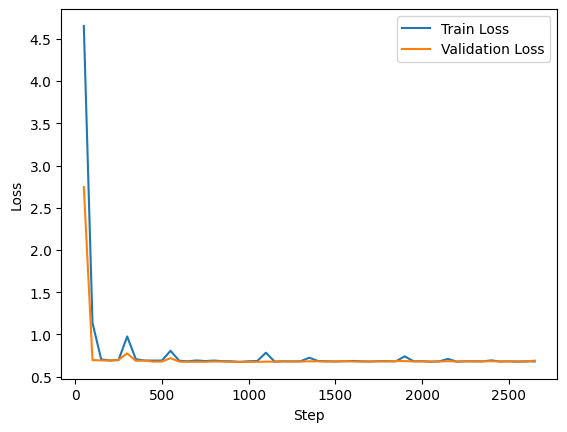

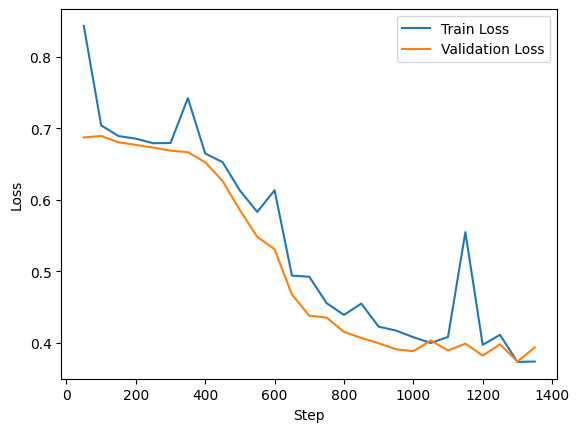

Test Accuracy: 0.8257575757575758

Train Accuracy: 0.8983787593984962

Validation Accuracy: 0.8465909090909091

In [ ]:
test_acc=calc_accuracy_loader(test_loader,model,device)

print(f"Test Accuracy: {test_acc}")

In [ ]:
train_acc=calc_accuracy_loader(train_loader,model,device)
val_acc=calc_accuracy_loader(val_loader,model,device)

print(f"Train Accuracy: {train_acc}")
print(f"Validation Accuracy: {val_acc}")

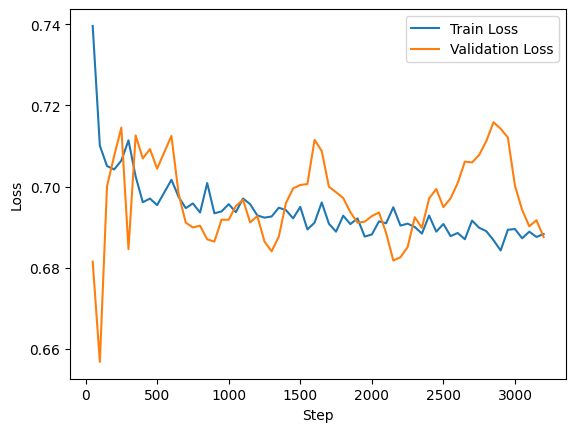

Pad Id를 데이터셋마다 collate_fn으로 뒤에 계속 붙이고 있었는데
[:,-1,:] 형태가 pad토큰의 hidden_state 까지 계산하고 있었던 것임.

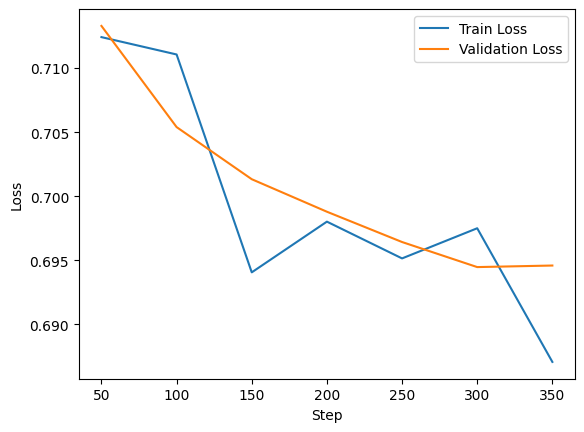